## Composition-aware plaquette classes

This model has three *chemically distinct* species — ABEF (4 rotations, indices 0–3),
BAEF (4 rotations, 4–7) and the solvent SSSS (index 8) — and the constraint rows below
(`A1`, `A2`, `A3`) are exactly their monomer fractions. That makes it the case where the
old class key does the most damage.

Microstates were grouped by their outgoing boundary-edge 4-tuple modulo the global $C_4$
rotation. A rotation does not change what a plaquette is made of, so collapsing the four
lab-frame images is exact. The boundary signature, however, does not determine the
composition: an ABEF corner and a BAEF corner can present the same outward patches, so
plaquettes with different ABEF/BAEF/solvent counts were merged into one class and
Boltzmann-averaged. `A1`, `A2`, `A3` were then fractional averages — off an integer count
of monomers by up to half a site — rather than exact counts, and the intra-class weights
still carried the $\mu$ used at build time.

`composition_key="components"` (the new default) keys a class on
(boundary signature, count per chemical component). A component is a set of species closed
under `rot90_species`, and for this model the orbit decomposition of
`rot90_species = [3,0,1,2, 7,4,5,6, 8]` is precisely
`{0,1,2,3}` = ABEF, `{4,5,6,7}` = BAEF, `{8}` = solvent — i.e. exactly the three groups the
constraint rows sum over, recovered with no extra input. Because components are unions of
rotation orbits the count vector is $C_4$-invariant, so the orientational collapse is
completely untouched: what separates is composition, not orientation.

Effect on this system, at every temperature in the scan:

| | classes $P$ | max $|A - \mathrm{round}(A)|$ |
|---|---|---|
| `composition_key="none"` (published) | 1044 | 0.5 |
| `composition_key="components"` | 1566 | 0 |

Pass `composition_key="none"` to reproduce the published construction.

In [1]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from typing import Optional, Callable, Dict, Any, Sequence

# Import species builder

# Import the SPECIES-BASED plaquette builder (identity = corner species, not edges)
from plaquette_by_species import *


In [3]:

class Particle:
    def __init__(self,index,patches=[],mu=0):
        self.patches=patches
        self.mu=mu
        self.index=index
        
    def get(self,i):
        return self.patches[i]
    def set_mu(self,mu):
        self.mu=mu
def get_species_list_ind(species):


    letter_to_index = {}  # mapping from letter to unique integer index
    next_index = 1
    particles = []
    letter_to_index['0']=0
    ind=0
    for s in species:
        n = len(s)
        # Create a base patch array of length 4 filled with zeros (0 means "no $
        base_array = np.zeros(4, dtype=int)
        # Right-align the string: fill positions 4 - n to 3 with the correspond$
        for i, letter in enumerate(s):
            if letter not in letter_to_index:
                letter_to_index[letter] = next_index
                next_index += 1
            base_array[4 - n + i] = letter_to_index[letter]
       
        
        # Generate all four rotations of the base array.
        unique_rotations = set()
        rotation_list = []  # to preserve an order (if needed)
        for r in range(4):
            rotated = np.roll(base_array, -r)  # rotate left by r positions
            tup = tuple(rotated.tolist())
            if tup not in unique_rotations:
                unique_rotations.add(tup)
                rotation_list.append(rotated)
        
        # For each distinct rotation, create a Particle object.
        for rot in rotation_list:
            particles.append(Particle(ind,patches=np.array(rot)))
            ind+=1
    
    return particles
# --------------------------------------------------------------------------
# Helper functions
# --------------------------------------------------------------------------

def detect_outliers_iqr(y, factor=2.0):
    """
    Detect outliers using IQR (Interquartile Range) method.
    Returns a boolean mask where True indicates outliers.
    """
    import numpy as np
    y_np = np.asarray(y)
    q1 = np.percentile(y_np, 25)
    q3 = np.percentile(y_np, 75)
    iqr = q3 - q1
    if iqr < 1e-10:
        # If IQR is too small, use MAD-based detection instead
        return detect_outliers_mad(y, factor=factor)
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    outliers = (y_np < lower_bound) | (y_np > upper_bound)
    return outliers

def detect_outliers_mad(y, factor=3.0):
    """
    Detect outliers using Median Absolute Deviation (MAD) method.
    More robust than IQR for small datasets.
    Returns a boolean mask where True indicates outliers.
    """
    import numpy as np
    y_np = np.asarray(y)
    median = np.median(y_np)
    mad = np.median(np.abs(y_np - median))
    if mad < 1e-10:
        # No variation, no outliers
        return np.zeros_like(y_np, dtype=bool)
    threshold = factor * mad
    outliers = np.abs(y_np - median) > threshold
    return outliers

def detect_outliers_local(y, window=5, factor=2.0):
    """
    Detect outliers by comparing each point to its local neighbors.
    More robust for detecting isolated spikes in smooth data.
    Returns a boolean mask where True indicates outliers.
    """
    import numpy as np
    y_np = np.asarray(y)
    n = len(y_np)
    outliers = np.zeros(n, dtype=bool)
    
    for i in range(n):
        # Get local window around point i
        start = max(0, i - window // 2)
        end = min(n, i + window // 2 + 1)
        local_window = y_np[start:end]
        # Exclude the current point from local statistics
        local_window = np.concatenate([local_window[:i-start], local_window[i-start+1:]])
        
        if len(local_window) < 2:
            continue
        
        local_median = np.median(local_window)
        local_mad = np.median(np.abs(local_window - local_median))
        
        if local_mad > 1e-10:
            deviation = np.abs(y_np[i] - local_median) / local_mad
            outliers[i] = deviation > factor
    
    return outliers

def loess_derivs(x, y, *, bandwidth=0.15, order=2, ignore_outliers=True, outlier_method='local', outlier_factor=2.5, trim_edges=True, edge_trim_fraction=0.05):
    """
    Compute LOESS derivatives, optionally ignoring outliers and trimming edge artifacts.
    
    Parameters:
    - ignore_outliers: If True, exclude outliers from smoothing computation
    - outlier_method: 'iqr', 'mad', or 'local' (default: 'local' for better spike detection)
    - outlier_factor: Threshold factor for outlier detection (default: 2.5)
    - trim_edges: If True, trim problematic edge points and use extrapolation (default: True)
    - edge_trim_fraction: Fraction of points at each end to treat as edges (default: 0.05)
    """
    x = torch.as_tensor(x, dtype=torch.float64)
    y = torch.as_tensor(y, dtype=torch.float64)
    n = x.shape[0]
    
    # Detect outliers if requested
    outlier_mask = None
    if ignore_outliers:
        if outlier_method == 'iqr':
            outlier_mask = detect_outliers_iqr(y.numpy(), factor=outlier_factor)
        elif outlier_method == 'mad':
            outlier_mask = detect_outliers_mad(y.numpy(), factor=outlier_factor)
        elif outlier_method == 'local':
            outlier_mask = detect_outliers_local(y.numpy(), window=7, factor=outlier_factor)
        else:
            raise ValueError(f"Unknown outlier_method: {outlier_method}")
        outlier_mask = torch.as_tensor(outlier_mask, dtype=torch.bool)
    
    f0 = torch.zeros(n, dtype=torch.float64)
    f1 = torch.zeros(n, dtype=torch.float64)
    f2 = torch.zeros(n, dtype=torch.float64)
    
    # Identify edge regions
    edge_size = max(1, int(n * edge_trim_fraction))
    edge_mask = torch.zeros(n, dtype=torch.bool)
    if trim_edges and n > 2 * edge_size:
        edge_mask[:edge_size] = True
        edge_mask[-edge_size:] = True
    
    # Use adaptive bandwidth: larger at edges to smooth out boundary effects
    h_base = bandwidth * (x.max() - x.min())
    
    for i in range(n):
        # Increase bandwidth at edges for better smoothing
        if trim_edges and edge_mask[i]:
            h = h_base * 1.5  # 50% larger bandwidth at edges
        else:
            h = h_base
        
        d = (x - x[i]).abs()
        w = torch.clamp(1 - (d / h) ** 3, min=0) ** 3
        
        # Zero out weights for outliers if ignoring them
        if ignore_outliers and outlier_mask is not None:
            w = w * (~outlier_mask).float()
            # If current point is an outlier, use interpolated value from neighbors
            if outlier_mask[i]:
                # For outliers, use weighted average of non-outlier neighbors
                valid_mask = ~outlier_mask & (w > 1e-10)
                if valid_mask.sum() > 0:
                    # Interpolate from neighbors
                    w_valid = w[valid_mask]
                    if w_valid.sum() > 1e-10:
                        # Weighted interpolation
                        f0[i] = (y[valid_mask] * w_valid).sum() / w_valid.sum()
                    else:
                        # Fallback to nearest neighbor
                        nearest_idx = torch.argmin(d[valid_mask])
                        valid_indices = torch.where(valid_mask)[0]
                        f0[i] = y[valid_indices[nearest_idx]]
                    # Set derivatives to NaN for outliers
                    f1[i] = torch.nan
                    f2[i] = torch.nan
                    continue
        
        dx = x - x[i]
        cols = [torch.ones_like(dx)]
        if order >= 1:
            cols.append(dx)
        if order >= 2:
            cols.append(dx ** 2)
        X = torch.stack(cols, dim=1)
        XTW = (X.T * w)
        
        # Only use non-outlier points for fitting
        valid_weights = w > 1e-10
        if valid_weights.sum() < order + 1:
            # Not enough points, use interpolation
            f0[i] = y[i]
            f1[i] = torch.nan
            f2[i] = torch.nan
            continue
        
        try:
            beta = torch.linalg.solve(XTW @ X, XTW @ y)
            f0[i] = beta[0]
            f1[i] = beta[1] if order >= 1 else torch.nan
            f2[i] = (2 * beta[2]) if order >= 2 else torch.nan
        except:
            # If solve fails, use simple interpolation
            f0[i] = y[i]
            f1[i] = torch.nan
            f2[i] = torch.nan
    
    # Post-process edges: smooth transition and extrapolate using interior points
    if trim_edges and n > 2 * edge_size:
        # Left edge: extrapolate from interior points
        interior_start = edge_size
        interior_end = min(edge_size + 3, n)
        if interior_end > interior_start:
            # Fit linear extrapolation from interior
            x_left = x[interior_start:interior_end]
            y_left = f0[interior_start:interior_end]
            # Linear fit for extrapolation
            dx_int = (x_left[1:] - x_left[:-1]).mean() if len(x_left) > 1 else x[1] - x[0]
            if abs(dx_int) > 1e-10:
                # Use slope from first two interior points
                slope_left = (y_left[1] - y_left[0]) / (x_left[1] - x_left[0]) if len(y_left) > 1 else 0.0
                for i in range(edge_size):
                    if i < len(y_left):
                        # Extrapolate
                        f0[i] = y_left[0] + slope_left * (x[i] - x_left[0])
                        # Use interior derivative
                        if not torch.isnan(f1[interior_start]):
                            f1[i] = f1[interior_start]
                        if not torch.isnan(f2[interior_start]):
                            f2[i] = f2[interior_start]
        
        # Right edge: extrapolate from interior points
        interior_start = max(0, n - edge_size - 3)
        interior_end = n - edge_size
        if interior_end > interior_start:
            x_right = x[interior_start:interior_end]
            y_right = f0[interior_start:interior_end]
            if len(y_right) > 1:
                # Use slope from last two interior points
                slope_right = (y_right[-1] - y_right[-2]) / (x_right[-1] - x_right[-2])
                for i in range(n - edge_size, n):
                    idx = i - (n - edge_size)
                    # Extrapolate
                    f0[i] = y_right[-1] + slope_right * (x[i] - x_right[-1])
                    # Use interior derivative
                    if not torch.isnan(f1[interior_end - 1]):
                        f1[i] = f1[interior_end - 1]
                    if not torch.isnan(f2[interior_end - 1]):
                        f2[i] = f2[interior_end - 1]
    
    return f0, f1, f2


class StepTracker:
    def __init__(self):
        self.data = []
    def log(self, **kwargs):
        self.data.append(kwargs)
    def as_list(self):
        return self.data


# --------------------------------------------------------------------------
# Binodal extraction via convex hull
# --------------------------------------------------------------------------
from scipy.spatial import ConvexHull

def extract_binodals_from_convex_envelope(phi, f, *, hull_tol=0.0, coexist_tol=1e-5, min_gap_points=6):
    """
    Find binodal points from the convex envelope of f(phi).
    Returns segments where the common tangent lies below the curve.
    """
    phi = np.asarray(phi, float)
    f = np.asarray(f, float)
    pts = np.column_stack([phi, f])
    try:
        hull = ConvexHull(pts)
    except Exception:
        return dict(phi=phi, f=f, hull_idx=[], segments=[])
    
    hull_idx = np.sort(hull.vertices)
    out = []
    for k in range(len(hull_idx) - 1):
        i, j = hull_idx[k], hull_idx[k + 1]
        if j - i < min_gap_points:
            continue
        phi1, phi2 = phi[i], phi[j]
        f1, f2 = f[i], f[j]
        mu_line = (f2 - f1) / (phi2 - phi1 + 1e-30)
        line = f1 + mu_line * (phi - phi1)
        diff = f - line
        mask = (phi >= phi1) & (phi <= phi2)
        if not np.any(mask):
            continue
        barrier = float(np.max(diff[mask]))
        below_min = float(np.min(diff[mask]))
        if barrier < coexist_tol:
            continue
        out.append(dict(phi1=float(phi1), phi2=float(phi2), mu=float(mu_line),
                        barrier=barrier, below_min=below_min, n_points=int(j - i)))
    return dict(phi=phi, f=f, hull_idx=hull_idx.tolist(), segments=out)


def best_binodal_segment(result, *, prefer="largest_barrier"):
    """Select the best binodal segment from convex hull analysis."""
    segs = result.get("segments", [])
    if not segs:
        return None
    if prefer == "widest":
        key = lambda d: (d["phi2"] - d["phi1"])
    elif prefer == "most_points":
        key = lambda d: d["n_points"]
    else:  # largest_barrier
        key = lambda d: ((d["phi2"] - d["phi1"]), d["barrier"])
    return max(segs, key=key)


def find_binodal_lower_envelope(phi, f, *, prefer="widest", min_gap_points=6, min_barrier=0.0):
    """
    Find a binodal candidate using the lower convex envelope of f(phi).

    Returns the best *skipping* segment of the lower hull. A skipping segment
    is a hull edge (phi1->phi2) that has at least one original sample point
    strictly between phi1 and phi2; these are the common-tangent coexistence
    candidates.

    Parameters
    - prefer: "widest" (default) or "largest_barrier"
      - "widest" picks the outermost coexistence region (usually what you want
        for a phase diagram)
      - "largest_barrier" can pick an inner/spurious tangent when the curve is
        only weakly non-convex or noisy
    - min_gap_points: require at least this many grid points between phi1, phi2
    - min_barrier: require barrier >= this value (helps ignore numerical noise)
    """
    phi = np.asarray(phi, float)
    f = np.asarray(f, float)
    n = len(phi)

    order = np.argsort(phi)
    phi_sorted = phi[order]
    f_sorted = f[order]

    # Build lower convex hull (monotone/Graham-scan style)
    lower = []
    for i in range(n):
        while len(lower) >= 2:
            p1 = lower[-2]
            p2 = lower[-1]
            p3 = (phi_sorted[i], f_sorted[i])
            cross = (p2[0] - p1[0]) * (p3[1] - p1[1]) - (p2[1] - p1[1]) * (p3[0] - p1[0])
            if cross <= 0:
                lower.pop()
            else:
                break
        lower.append((phi_sorted[i], f_sorted[i]))

    lower = np.asarray(lower, float)

    candidates = []
    for k in range(len(lower) - 1):
        phi1, f1 = lower[k]
        phi2, f2 = lower[k + 1]

        # count interior points on the original grid
        mask = (phi > phi1 + 1e-12) & (phi < phi2 - 1e-12)
        n_between = int(np.sum(mask))
        if n_between < min_gap_points:
            continue

        slope = (f2 - f1) / (phi2 - phi1)
        line_vals = f1 + slope * (phi[mask] - phi1)
        diff = f[mask] - line_vals
        barrier = float(np.max(diff))
        if barrier < min_barrier:
            continue

        candidates.append(dict(
            phi1=float(phi1), phi2=float(phi2),
            f1=float(f1), f2=float(f2),
            mu=float(slope), barrier=barrier,
            width=float(phi2 - phi1), n_between=n_between,
        ))

    if not candidates:
        return None

    if prefer == "largest_barrier":
        return max(candidates, key=lambda d: (d["barrier"], d["width"]))
    # default: outermost coexistence
    return max(candidates, key=lambda d: (d["width"], d["barrier"]))

def subtract_linear_part(phi, f, ignore_outliers=True, outlier_method='local', outlier_factor=2.5):
    """
    Subtract linear fit from f to reveal double-well structure.
    Optionally ignores outliers when fitting the linear part.
    
    Parameters:
    - ignore_outliers: If True, exclude outliers from linear fit
    - outlier_method: 'iqr', 'mad', or 'local' (default: 'local' for better spike detection)
    - outlier_factor: Threshold factor for outlier detection (default: 2.5)
    """
    phi = np.asarray(phi, float)
    f = np.asarray(f, float)
    
    # Detect outliers if requested
    outlier_mask = None
    if ignore_outliers:
        if outlier_method == 'iqr':
            outlier_mask = detect_outliers_iqr(f, factor=outlier_factor)
        elif outlier_method == 'mad':
            outlier_mask = detect_outliers_mad(f, factor=outlier_factor)
        elif outlier_method == 'local':
            outlier_mask = detect_outliers_local(f, window=7, factor=outlier_factor)
        else:
            raise ValueError(f"Unknown outlier_method: {outlier_method}")
        
        # Use non-outlier points for linear fit
        valid_mask = ~outlier_mask
        if valid_mask.sum() < 2:
            # Not enough points, use all points
            valid_mask = np.ones_like(phi, dtype=bool)
        phi_fit = phi[valid_mask]
        f_fit = f[valid_mask]
    else:
        phi_fit = phi
        f_fit = f
    
    # Linear fit: f = a*phi + b
    A = np.vstack([phi_fit, np.ones_like(phi_fit)]).T
    slope, intercept = np.linalg.lstsq(A, f_fit, rcond=None)[0]
    linear_part = slope * phi + intercept
    return f - linear_part, slope, intercept



In [4]:

def find_spinodal_chirality_species(
    patches, Ts, factor, *,mu=None,
    rho_empty=0.5, z=4, lr=0.05, tol=1e-4, rot90_species=None,use_4_patch=False,
    J_template=None, n_phi=101, canonicalize_by_boundary_edges=True, canonicalize_by_edges=True,undir=False,
    composition_key="components"
):
    """
    Scan temperature Ts, find spinodals using SPECIES-BASED plaquettes.
    
    Plaquette identity = canonical species configuration (not edges).
    
    Constraints:
      - A1 (ABEE rotations 0-3) = phi (variable)
      - A3 (CD rotations 8-11) = rho_cd (fixed)
      - A4 (vacancy = species 12) = rho_empty (fixed)
      - A2 (BAEE rotations 4-7) = 1 - phi - rho_cd - rho_empty (implied)
    """
    spinodal = [None] * len(Ts)
    bounds = [None] * len(Ts)
    binodals = [None] * len(Ts)
    
    n_patch_types = patches.max() + 1
    
    for j, T in enumerate(Ts):
        print(f"T = {T:.3f}")
        
        # Build J matrix for this temperature
        if J_template is not None:
            J = J_template.copy() / T
        else:
            J = np.zeros((n_patch_types, n_patch_types))
            J[1, 4] = -3; J[2, 4] = 0
            J[1, 5] = 0; J[2, 5] = -3
            J[3, 3] = -1
            J = (J + J.T) / T
        if mu is None:  
            mu = np.zeros(len(patches))
        
        # Build plaquettes with SPECIES-BASED grouping
        (eps_s, intra_bonds, plaq_to_species, m_patch, patch_to_species, patch_to_small,
         plaq_configs, mult) = build_plaquettes_by_species(
            patches, J, mu, rot90_species, use_4_patch=use_4_patch,undirected_edges=undir,
                canonicalize_by_boundary_edges=canonicalize_by_boundary_edges, 
                canonicalize_by_edges=canonicalize_by_edges,
                # Class key = (boundary signature, per-chemical-component counts).
                # Without this a class mixes ABEF-, BAEF- and solvent-rich
                # microstates and A1/A2/A3 below become Boltzmann averages
                # rather than exact monomer counts.  "none" = published key.
                composition_key=composition_key
        )
        
        # Build A rows
        A_all = build_A_rows_from_plaq(plaq_to_species)
        n_species = A_all.shape[0]
        P_macro = A_all.shape[1]
        print(f"  n_plaq={P_macro}, n_species={n_species}")
        
        # Build composite A rows by summing over species groups
        # Divide by 4 to get monomer fractions (each plaquette has 4 monomers)
        A1 = A_all[0:4].sum(axis=0) / 4.0    # ABEE fraction
        A2 = A_all[4:8].sum(axis=0) / 4.0    # BAEE fraction
        A3 = A_all[8:9].sum(axis=0) / 4.0  # SSSS (vacancy) fraction
        
        A_rows = np.vstack([A1,A3])
        targets_template = np.array([np.nan, rho_empty], dtype=float)
        
        # Torch tensors
        patch_to_species_t = torch.from_numpy(patch_to_species).long()
        patch_to_small_t = torch.from_numpy(patch_to_small).long()
        eps_small_t = torch.tensor(-eps_s, dtype=torch.float64)
        m_patch_t = torch.from_numpy(m_patch).double()
        mult_t = torch.from_numpy(mult).double()
        e_linear_t = torch.tensor(intra_bonds, dtype=torch.float64)
        
        Δ_small = torch.expm1(eps_small_t).div(factor)
        def f_tilde_torch(rho_t):
            # NOTE: eps_small / intra_bonds are already scaled by 1/T upstream (J = J_template / T)
            # so residual_free_energy_by_species returns a dimensionless beta*F. Pass beta=1.
            f_val = residual_free_energy_by_species(
                rho_t, 1.0, z,
                patch_to_species_t, patch_to_small_t, eps_small_t, m_patch_t,
                e_linear_t, Δ_small, mult_t,
            )
            return f_val
        
        # Phi scan with fewer points for stability
        phis = np.linspace(0.01,1-rho_empty-0.01,n_phi)
        
        # This is the expensive part (one constrained optimization per phi).
        curve = free_energy_curve_chirality(
            phis, A_rows, targets_template, variable_idx=0,
            f_tilde_torch=f_tilde_torch,
            device="cpu", dtype=torch.float64,
            steps=10000, lr=lr, tol_res=tol,
        )


        # ------------------------------------------------------------------
        # Diagnostic: do boundary patch-type marginals change with phi?
        # If they are (nearly) constant vs phi, then the association term (and
        # most energetic terms) are effectively phi-independent, so the model
        # cannot produce a widening coexistence region as T decreases.
        # ------------------------------------------------------------------
        try:
            with torch.no_grad():
                W_list = []
                for rho_np in curve["rhos"]:
                    rho_t = torch.tensor(rho_np, dtype=torch.float64)
                    W = torch.zeros(int(eps_small_t.shape[0]), dtype=torch.float64)
                    # expected boundary patch counts per patch type
                    W.index_add_(0, patch_to_small_t, m_patch_t * rho_t[patch_to_species_t])
                    W = W / W.sum().clamp_min(1e-30)
                    W_list.append(W.numpy())
                Wm = np.stack(W_list, axis=0)
                max_var = np.max(Wm, axis=0) - np.min(Wm, axis=0)
                print(f"  boundary patch frac max Δ over phi: {max_var.max():.3e}")
        except Exception as _e:
            print(f"  (diag skipped: {type(_e).__name__})")
        
        # ------------------------------
        # No ABEE<->BAEE symmetrization.
        # If interactions distinguish enantiomers, the free energy need not satisfy
        # f(phi) = f(phi_total - phi), and the coexistence curve can be tilted.
        # ------------------------------
        phi = np.asarray(curve['phi'], float)
        f_raw = np.asarray(curve['f'], float)
        phi_total = 1.0 - float(rho_empty)
        phi_star = 0.5 * phi_total
        #f_raw= f_raw[::-1]
        #phi=phi[::-1]
        # Subtract linear part for visualization
        f_detrend, slope, intercept = subtract_linear_part(phi, f_raw)

        # Find binodal using lower convex envelope (proper common tangent)
        # Use LOESS smoothed data to reduce noise effects
        f_smooth_raw, _, _ = loess_derivs(
            torch.tensor(phi), torch.tensor(f_raw), 
            bandwidth=0.15, trim_edges=True, edge_trim_fraction=0.05
        )
        f_smooth_raw = f_smooth_raw.numpy()

        # Find binodal from lower convex envelope.
        # Prefer the *widest* coexistence segment (outermost binodal) and
        # require a small minimum barrier to avoid noise-picked tangents.
        binodal_seg = find_binodal_lower_envelope(
            phi, f_smooth_raw,
            prefer="widest",
            min_gap_points=max(6, int(0.1 * len(phi))),
            min_barrier=1e-6,
        )
        
        # Use LOESS smoothing on detrended curve for visualization
        f_smooth_det, fp_smooth, fpp_smooth = loess_derivs(
            torch.tensor(phi), torch.tensor(f_detrend), 
            bandwidth=0.2, trim_edges=True, edge_trim_fraction=0.05
        )
        f_smooth_det = f_smooth_det.numpy()
        
        plt.figure(figsize=(12, 4))
        
        # Left: Detrended free energy (reveals double-well)
        plt.subplot(1, 3, 1)
        plt.plot(phi, f_detrend, 'o', ms=3, alpha=0.5, label='raw - linear')
        plt.plot(phi, f_smooth_det, '-', lw=2, label='LOESS smooth')
        if binodal_seg:
            plt.axvline(binodal_seg['phi1'], c='g', ls='--', lw=2, label='binodal')
            plt.axvline(binodal_seg['phi2'], c='g', ls='--', lw=2)
        plt.xlabel('phi (ABEE)'); plt.ylabel('f - linear')
        plt.legend()
        plt.title(f'T = {T:.3f} (detrended)')
        
        # Middle: Free energy (raw) with common tangent
        plt.subplot(1, 3, 2)
        plt.plot(phi, f_raw, 'o-', ms=3, alpha=0.35, label='raw f(phi)')
        plt.axvline(phi_star, c='k', ls=':', lw=1, label='phi* = (phi_total)/2')
        if binodal_seg:
            # Plot common tangent line (computed on LOESS-smoothed raw curve)
            phi1, phi2 = binodal_seg['phi1'], binodal_seg['phi2']
            f1 = np.interp(phi1, phi, f_smooth_raw)
            f2 = np.interp(phi2, phi, f_smooth_raw)
            plt.plot([phi1, phi2], [f1, f2], 'g-', lw=2, label='common tangent')
            plt.plot([phi1, phi2], [f1, f2], 'go', ms=8)
        plt.xlabel('phi (ABEE)'); plt.ylabel('f')
        plt.legend()
        plt.title('Free energy (raw)')
        
        # Right: Second derivative
        plt.subplot(1, 3, 3)
        plt.plot(curve['phi_inner'], -curve['fpp'].numpy(), label="-f''(phi)")
        plt.axhline(0, c='k', ls='--', alpha=0.5)
        plt.xlabel('phi'); plt.ylabel("-f''")
        plt.ylim([-5, 5])
        for sp in curve['spinodal_phis']:
            plt.axvline(sp, c='r', ls='--', alpha=0.5, 
                        label='spinodal' if sp == curve['spinodal_phis'][0] else '')
        if binodal_seg:
            plt.axvline(binodal_seg['phi1'], c='g', ls='-', lw=2, label='binodal')
            plt.axvline(binodal_seg['phi2'], c='g', ls='-', lw=2)
        plt.legend()
        plt.title('Curvature')
        
        plt.tight_layout()
        plt.show()
        
        # Store results
        phi_spi = np.asarray(curve["spinodal_phis"], dtype=float)
        if binodal_seg:
            print(
                f"  -> Binodal: phi1={binodal_seg['phi1']:.3f}, phi2={binodal_seg['phi2']:.3f}, "
                f"barrier={binodal_seg['barrier']:.2e}"
            )
            binodals[j] = binodal_seg
        if phi_spi.size > 1:
            print(f"  -> Spinodal at phi = {curve['spinodal_phis']}")
            spinodal[j] = curve
            bounds[j] = phi_spi
    
    return spinodal, bounds, binodals

In [5]:
import json
import os
from pathlib import Path

def save_spinodal_results(
    spinodal_results, bounds_results, binodal_results,
    Ts, factor, patches, J_template, rot90_species,
    rho_empty=0.5, z=4,
    filename="../data/spinodal_results.npz",
    metadata_filename="../data/spinodal_metadata.json"
):
    """
    Save results from find_spinodal_chirality_species to disk.
    
    Args:
        spinodal_results: List of curve dictionaries (one per T, or None)
        bounds_results: List of spinodal bounds (one per T, or None)
        binodal_results: List of binodal segments (one per T, or None)
        Ts: Temperature array
        factor: Association factor
        patches: Patches array
        J_template: J template matrix
        rot90_species: Rotation mapping
        filename: Output .npz file for arrays
        metadata_filename: Output .json file for metadata
    """
    # Prepare arrays for saving
    save_dict = {}
    
    # Save temperature array
    save_dict['Ts'] = np.array(Ts, dtype=np.float64)
    
    # Save spinodal results (curves)
    spinodal_phis_all = []
    spinodal_f_all = []
    spinodal_phi_grid_all = []
    spinodal_rhos_all = []
    spinodal_valid = []
    
    for j, curve in enumerate(spinodal_results):
        if curve is not None:
            spinodal_valid.append(j)
            spinodal_phis_all.append(np.array(curve.get('spinodal_phis', []), dtype=np.float64))
            spinodal_f_all.append(np.array(curve.get('f', []), dtype=np.float64))
            spinodal_phi_grid_all.append(np.array(curve.get('phi', []), dtype=np.float64))
            # Save rhos as a list of arrays (variable length per temperature)
            rhos_list = curve.get('rhos', [])
            if rhos_list:
                # Stack into a single array with shape (n_phi, n_plaquettes)
                spinodal_rhos_all.append(np.stack(rhos_list))
            else:
                spinodal_rhos_all.append(np.array([]))
        else:
            spinodal_valid.append(-1)  # Mark as invalid
    
    save_dict['spinodal_valid'] = np.array(spinodal_valid, dtype=np.int32)
    # Save lists of arrays using object arrays (requires allow_pickle=True on load)
    save_dict['spinodal_phis'] = np.array(spinodal_phis_all, dtype=object)
    save_dict['spinodal_f'] = np.array(spinodal_f_all, dtype=object)
    save_dict['spinodal_phi_grid'] = np.array(spinodal_phi_grid_all, dtype=object)
    
    # Save bounds results
    bounds_all = []
    bounds_valid = []
    for j, bounds in enumerate(bounds_results):
        if bounds is not None:
            bounds_valid.append(j)
            bounds_all.append(np.array(bounds, dtype=np.float64))
        else:
            bounds_valid.append(-1)
    
    save_dict['bounds_valid'] = np.array(bounds_valid, dtype=np.int32)
    save_dict['bounds'] = np.array(bounds_all, dtype=object)
    
    # Save binodal results
    binodal_phi1_all = []
    binodal_phi2_all = []
    binodal_f1_all = []
    binodal_f2_all = []
    binodal_valid = []
    
    for j, binodal in enumerate(binodal_results):
        if binodal is not None and isinstance(binodal, dict):
            binodal_valid.append(j)
            binodal_phi1_all.append(float(binodal.get('phi1', np.nan)))
            binodal_phi2_all.append(float(binodal.get('phi2', np.nan)))
            binodal_f1_all.append(float(binodal.get('f1', np.nan)))
            binodal_f2_all.append(float(binodal.get('f2', np.nan)))
        else:
            binodal_valid.append(-1)
            binodal_phi1_all.append(np.nan)
            binodal_phi2_all.append(np.nan)
            binodal_f1_all.append(np.nan)
            binodal_f2_all.append(np.nan)
    
    save_dict['binodal_valid'] = np.array(binodal_valid, dtype=np.int32)
    save_dict['binodal_phi1'] = np.array(binodal_phi1_all, dtype=np.float64)
    save_dict['binodal_phi2'] = np.array(binodal_phi2_all, dtype=np.float64)
    save_dict['binodal_f1'] = np.array(binodal_f1_all, dtype=np.float64)
    save_dict['binodal_f2'] = np.array(binodal_f2_all, dtype=np.float64)
    
    # Save rhos separately (they're large and variable-length)
    # We'll save them in a separate file or handle them specially
    np.savez_compressed(filename, **save_dict)
    
    # Save metadata as JSON
    metadata = {
        'factor': float(factor),
        'rho_empty': float(rho_empty),
        'z': int(z),
        'patches_shape': list(patches.shape) if patches is not None else None,
        'J_template_shape': list(J_template.shape) if J_template is not None else None,
        'rot90_species': rot90_species.tolist() if rot90_species is not None else None,
        'n_temperatures': len(Ts),
    }
    
    with open(metadata_filename, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"Saved results to {filename} and {metadata_filename}")
    
    # Save rhos separately if they exist (they can be large)
    if spinodal_rhos_all:
        rhos_filename = filename.replace('.npz', '_rhos.npz')
        rhos_dict = {}
        for j, rhos_array in enumerate(spinodal_rhos_all):
            if rhos_array.size > 0:
                rhos_dict[f'rhos_T{j}'] = rhos_array
        if rhos_dict:
            np.savez_compressed(rhos_filename, **rhos_dict)
            print(f"Saved rhos to {rhos_filename}")


def load_spinodal_results(
    filename="../data/spinodal_results.npz",
    metadata_filename="../data/spinodal_metadata.json",
    load_rhos=True
):
    """
    Load results from find_spinodal_chirality_species from disk.
    
    Args:
        filename: Input .npz file for arrays
        metadata_filename: Input .json file for metadata
        load_rhos: Whether to load the rhos arrays (can be large)
    
    Returns:
        spinodal_results, bounds_results, binodal_results, metadata
    """
    # Load arrays
    data = np.load(filename, allow_pickle=True)
    
    Ts = data['Ts']
    n_T = len(Ts)
    # Reconstruct spinodal results
    spinodal_results = [None] * n_T
    spinodal_valid = data['spinodal_valid']
    # Handle object arrays (lists of arrays)
    spinodal_phis = data['spinodal_phis']
    spinodal_f = data['spinodal_f']
    spinodal_phi_grid = data['spinodal_phi_grid']
    # Convert object arrays back to lists
    if spinodal_phis.dtype == object:
        spinodal_phis = [spinodal_phis[i] for i in range(len(spinodal_phis))]
        spinodal_f = [spinodal_f[i] for i in range(len(spinodal_f))]
        spinodal_phi_grid = [spinodal_phi_grid[i] for i in range(len(spinodal_phi_grid))]
    
    # Load rhos if requested
    rhos_data = None
    if load_rhos:
        rhos_filename = filename.replace('.npz', '_rhos.npz')
        if os.path.exists(rhos_filename):
            rhos_data = np.load(rhos_filename, allow_pickle=True)
    
    # Build a mapping from temperature index to array index
    # The arrays only contain valid curves, so we need to track position separately
    array_idx = 0
    for j in range(n_T):
        if spinodal_valid[j] >= 0:
            curve = {
                'phi': spinodal_phi_grid[array_idx],
                'f': spinodal_f[array_idx],
                'spinodal_phis': spinodal_phis[array_idx].tolist() if spinodal_phis[array_idx].size > 0 else [],
            }
            array_idx += 1
            # Load rhos if available
            if rhos_data is not None:
                rhos_key = f'rhos_T{j}'
                if rhos_key in rhos_data:
                    rhos_array = rhos_data[rhos_key]
                    # Convert back to list of arrays
                    curve['rhos'] = [rhos_array[i] for i in range(len(rhos_array))]
                else:
                    curve['rhos'] = []
            else:
                curve['rhos'] = []
            
            spinodal_results[j] = curve
    
    # Reconstruct bounds results
    bounds_results = [None] * n_T
    bounds_valid = data['bounds_valid']
    bounds = data['bounds']
    # Convert object array back to list if needed
    if bounds.dtype == object:
        bounds = [bounds[i] for i in range(len(bounds))]
    # Build a mapping from temperature index to array index
    # The bounds array only contains valid bounds, so we need to track position separately
    bounds_array_idx = 0
    for j in range(n_T):
        if bounds_valid[j] >= 0:
            bounds_results[j] = bounds[bounds_array_idx]
            bounds_array_idx += 1
    
    # Reconstruct binodal results
    binodal_results = [None] * n_T
    binodal_valid = data['binodal_valid']
    for j in range(n_T):
        if binodal_valid[j] >= 0:
            binodal_results[j] = {
                'phi1': float(data['binodal_phi1'][j]),
                'phi2': float(data['binodal_phi2'][j]),
                'f1': float(data['binodal_f1'][j]),
                'f2': float(data['binodal_f2'][j]),
            }
    
    # Load metadata
    with open(metadata_filename, 'r') as f:
        metadata = json.load(f)
    
  
    
    return spinodal_results, bounds_results, binodal_results, metadata


In [6]:
# --------------------------------------------------------------------------
# Setup: Species and parameters
# --------------------------------------------------------------------------

# Species names and their rotations
species_names = ['ABEF', 'BAEF', 'SSSS']
ns = len(species_names)

# Get species list with all rotations
species = get_species_list_ind(species_names)
n = len(species)

print(f"Species names: {species_names}")
print(f"Number of species (with rotations): {n}")

# Extract patches array
patches = np.array([s.patches for s in species])
print(f"Patches shape: {patches.shape}")
print("Patches:")
for i, p in enumerate(patches):
    print(f"  {i}: {p}")

# Rotation mapping: species i -> species rot90_species[i] under 90° rotation
rot90_species = np.array([3, 0, 1, 2, 7, 4, 5, 6,8], dtype=np.int64)
print(f"\nrot90_species: {rot90_species}")

# --------------------------------------------------------------------------
# Find patch types and build J matrix
# --------------------------------------------------------------------------

n_patch_types = patches.max() + 1
print(f"Number of patch types: {n_patch_types}")

# Build J template (before dividing by T)
# Patch type mapping from get_species_list_ind:
# 0=empty, 1=A, 2=B, 3=E, 4=C, 5=D, 6=S
J_template = np.zeros((n_patch_types, n_patch_types))
J_template[1, 3] = -3  # A-C
J_template[2, 4] = -3  # B-D
J_template[3, 3] = -1  # E-E self
J_template[4, 4] = -1  # D-D self
J_template = J_template + J_template.T  # Symmetrize

print("J_template (before /T):")
print(J_template)


Species names: ['ABEF', 'BAEF', 'SSSS']
Number of species (with rotations): 9
Patches shape: (9, 4)
Patches:
  0: [1 2 3 4]
  1: [2 3 4 1]
  2: [3 4 1 2]
  3: [4 1 2 3]
  4: [2 1 3 4]
  5: [1 3 4 2]
  6: [3 4 2 1]
  7: [4 2 1 3]
  8: [5 5 5 5]

rot90_species: [3 0 1 2 7 4 5 6 8]
Number of patch types: 6
J_template (before /T):
[[ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -3.  0.  0.]
 [ 0.  0.  0.  0. -3.  0.]
 [ 0. -3.  0. -2.  0.  0.]
 [ 0.  0. -3.  0. -2.  0.]
 [ 0.  0.  0.  0.  0.  0.]]


In [7]:
# Build plaquettes with SPECIES-BASED grouping
(eps_s, intra_bonds, plaq_to_species, m_patch, patch_to_species, patch_to_small,
 plaq_configs, mult) = build_plaquettes_by_species(
    patches, J_template, np.zeros(len(patches)), rot90_species, use_4_patch=True,
        canonicalize_by_boundary_edges=True, 
        canonicalize_by_edges=False,
        composition_key="components"
)

# Each class must now hold an integer number of monomers of each chemical
# component; under the published key these were half-integer Boltzmann averages.
for _lo, _hi, _lab in [(0, 4, "ABEF"), (4, 8, "BAEF"), (8, 9, "solvent")]:
    _A = plaq_to_species[:, _lo:_hi].sum(axis=1)
    print(f"{_lab:8s} range [{_A.min():.3f}, {_A.max():.3f}]  "
          f"max|A - round(A)| = {np.abs(_A - np.rint(_A)).max():.3e}")
print("classes:", len(intra_bonds))

ABEF     range [0.000, 4.000]  max|A - round(A)| = 1.776e-15
BAEF     range [0.000, 4.000]  max|A - round(A)| = 1.776e-15
solvent  range [0.000, 4.000]  max|A - round(A)| = 0.000e+00
classes: 1566


In [7]:
plaq_to_species

array([[9.99381844e-01, 9.99381844e-01, 9.99381844e-01, ...,
        6.18155789e-04, 6.18155789e-04, 0.00000000e+00],
       [7.50000000e-01, 7.50000000e-01, 7.50000000e-01, ...,
        2.50000000e-01, 2.50000000e-01, 0.00000000e+00],
       [9.88143532e-01, 9.88143532e-01, 9.88143532e-01, ...,
        1.18564683e-02, 1.18564683e-02, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.00000000e-01, 5.00000000e-01, 2.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.50000000e-01, 2.50000000e-01, 3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 4.00000000e+00]])

Temperature grid: [0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
Factor: 4

Running scan: compress_boundary=False, canonicalize_by_edges=True
T = 0.500
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.flo

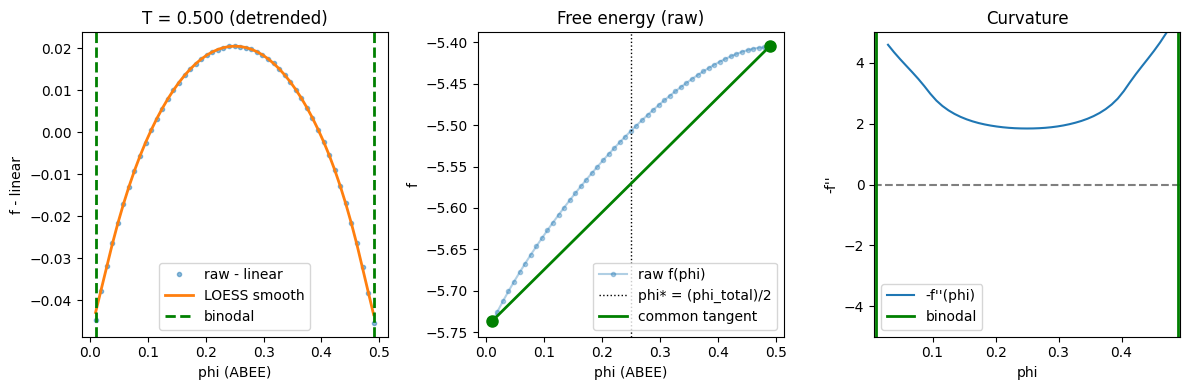

  -> Binodal: phi1=0.010, phi2=0.490, barrier=6.37e-02
T = 0.600
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828, 0.5000], dtype=torch.float64)
tensor([0.1924, 0.5000], dtype=tor

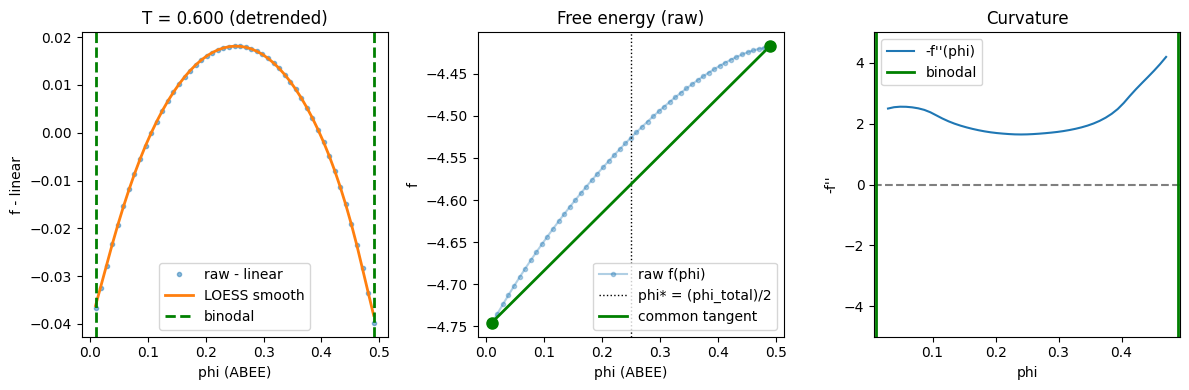

  -> Binodal: phi1=0.010, phi2=0.490, barrier=5.53e-02
T = 0.700
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828, 0.5000], dtype=torch.float64)
tensor([0.1924, 0.5000], dtype=tor

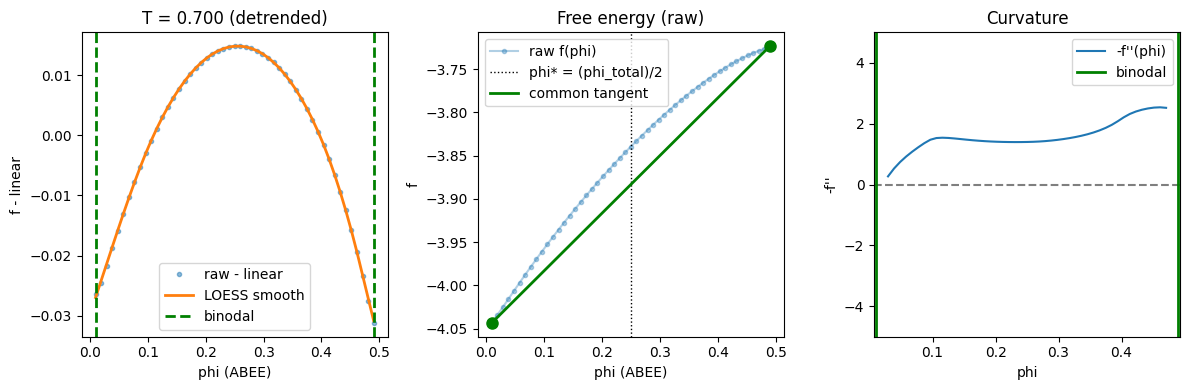

  -> Binodal: phi1=0.010, phi2=0.490, barrier=4.39e-02
T = 0.800
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828, 0.5000], dtype=torch.float64)
tensor([0.1924, 0.5000], dtype=tor

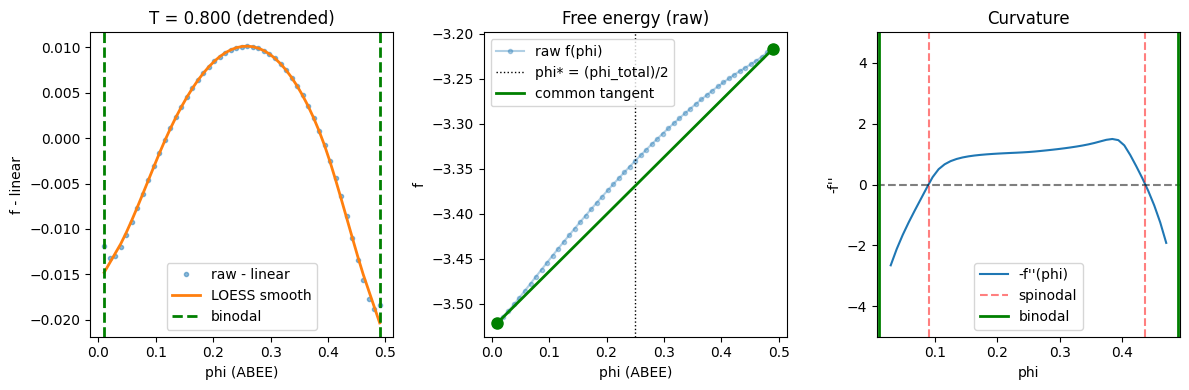

  -> Binodal: phi1=0.010, phi2=0.490, barrier=2.80e-02
  -> Spinodal at phi = [0.08985379738205404, 0.4372259669560094]
T = 0.900
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828,

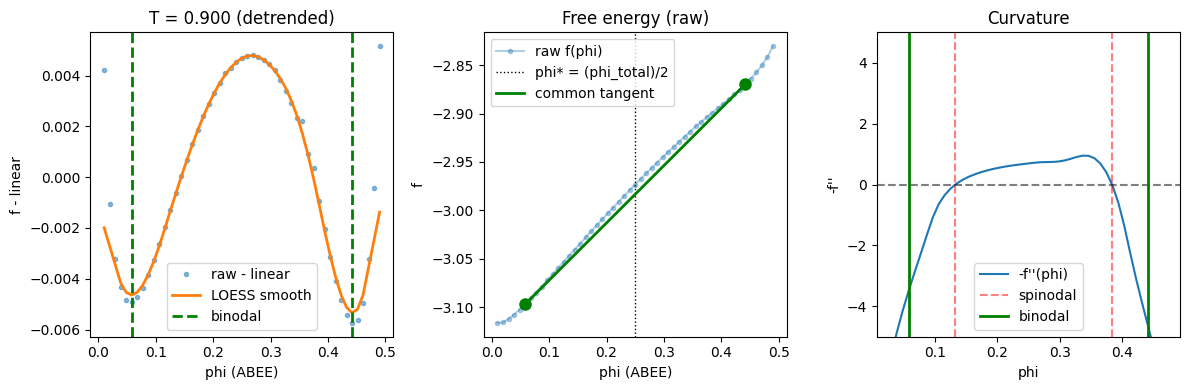

  -> Binodal: phi1=0.058, phi2=0.442, barrier=1.02e-02
  -> Spinodal at phi = [0.13288979722883892, 0.38395210164784693]
T = 1.000
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828

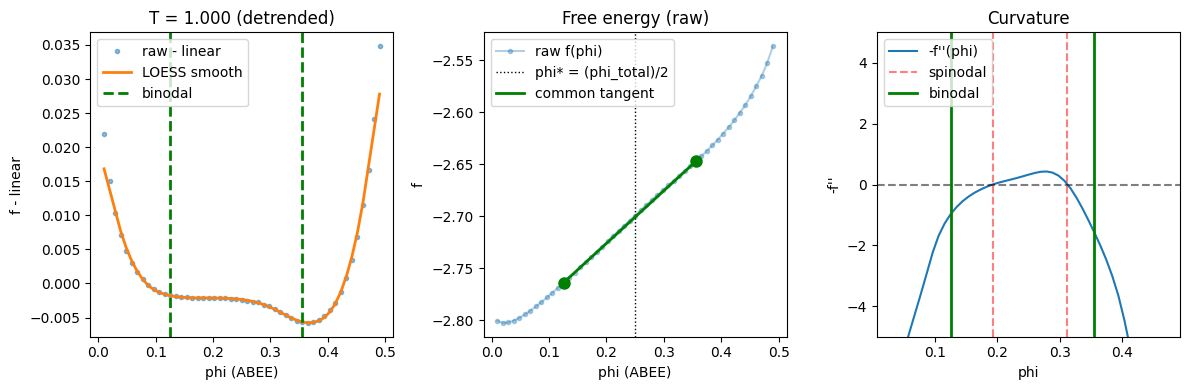

  -> Binodal: phi1=0.125, phi2=0.356, barrier=1.58e-03
  -> Spinodal at phi = [0.19236032623662636, 0.31245043746892687]
T = 1.100
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828

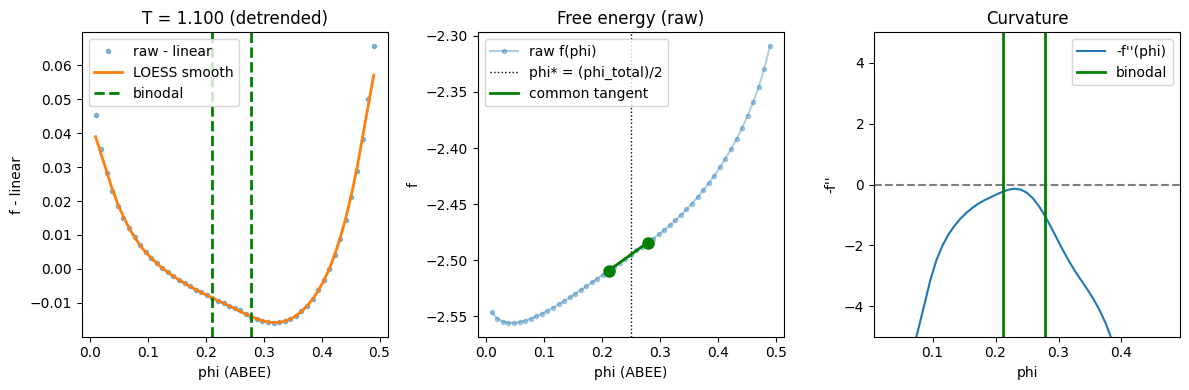

  -> Binodal: phi1=0.212, phi2=0.279, barrier=5.82e-05
T = 1.200
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828, 0.5000], dtype=torch.float64)
tensor([0.1924, 0.5000], dtype=tor

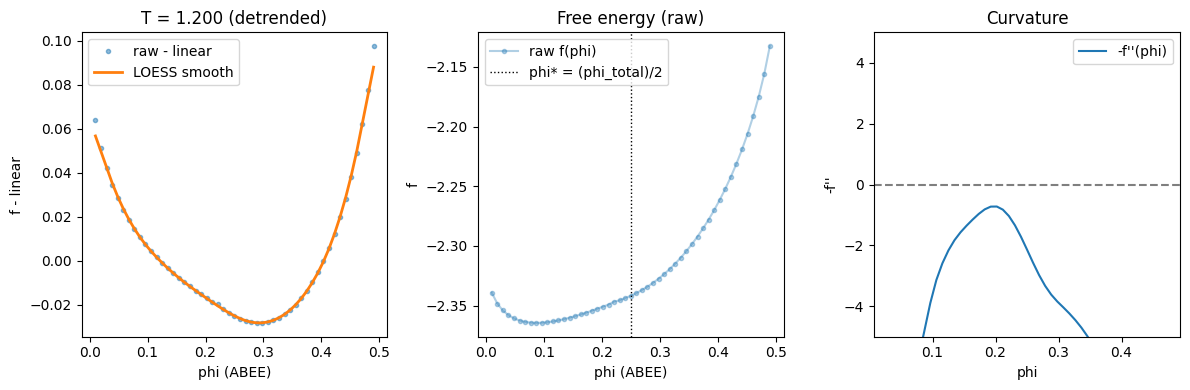

T = 1.300
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828, 0.5000], dtype=torch.float64)
tensor([0.1924, 0.5000], dtype=torch.float64)
tensor([0.2020, 0.5000], dtype=torch.float6

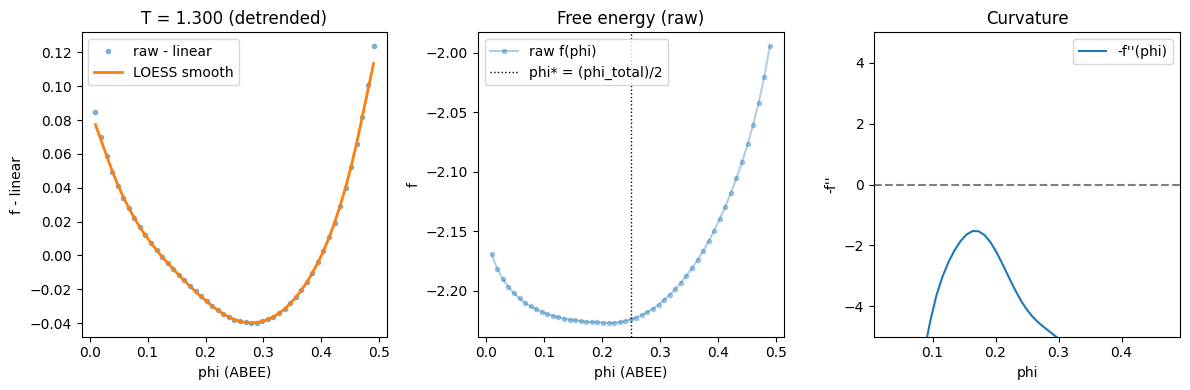

T = 1.400
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828, 0.5000], dtype=torch.float64)
tensor([0.1924, 0.5000], dtype=torch.float64)
tensor([0.2020, 0.5000], dtype=torch.float6

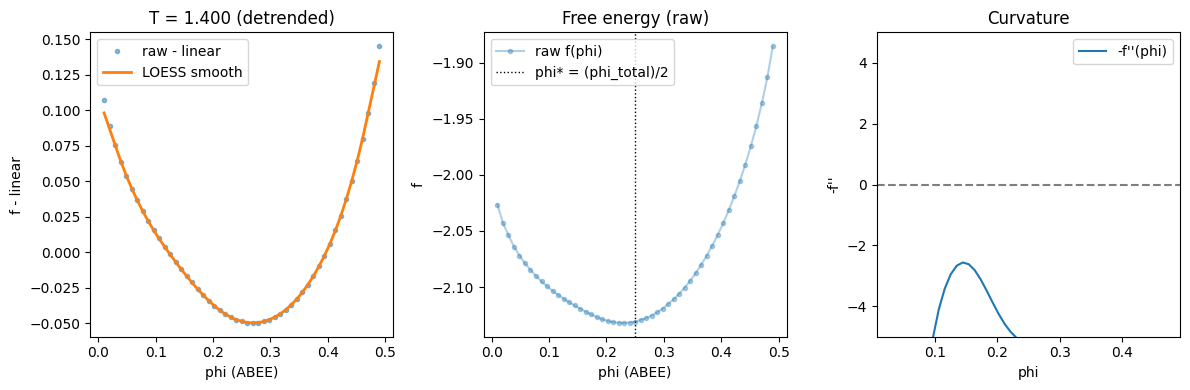

T = 1.500
  n_plaq=1566, n_species=9
tensor([0.0100, 0.5000], dtype=torch.float64)
tensor([0.0196, 0.5000], dtype=torch.float64)
tensor([0.0292, 0.5000], dtype=torch.float64)
tensor([0.0388, 0.5000], dtype=torch.float64)
tensor([0.0484, 0.5000], dtype=torch.float64)
tensor([0.0580, 0.5000], dtype=torch.float64)
tensor([0.0676, 0.5000], dtype=torch.float64)
tensor([0.0772, 0.5000], dtype=torch.float64)
tensor([0.0868, 0.5000], dtype=torch.float64)
tensor([0.0964, 0.5000], dtype=torch.float64)
tensor([0.1060, 0.5000], dtype=torch.float64)
tensor([0.1156, 0.5000], dtype=torch.float64)
tensor([0.1252, 0.5000], dtype=torch.float64)
tensor([0.1348, 0.5000], dtype=torch.float64)
tensor([0.1444, 0.5000], dtype=torch.float64)
tensor([0.1540, 0.5000], dtype=torch.float64)
tensor([0.1636, 0.5000], dtype=torch.float64)
tensor([0.1732, 0.5000], dtype=torch.float64)
tensor([0.1828, 0.5000], dtype=torch.float64)
tensor([0.1924, 0.5000], dtype=torch.float64)
tensor([0.2020, 0.5000], dtype=torch.float6

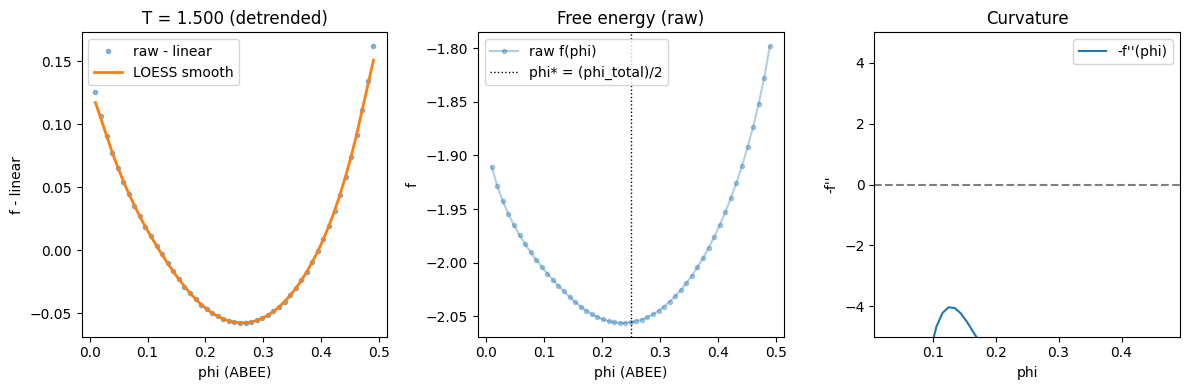

Saved results to ../data/spinodal_results_small4_canon_boundary_corr.npz and ../data/spinodal_metadata_small4_canon_boundary_corr.json
Saved rhos to ../data/spinodal_results_small4_canon_boundary_corr_rhos.npz


In [8]:
# --------------------------------------------------------------------------
# Run spinodal scan: compress=False, edges=True
# --------------------------------------------------------------------------

Ts = np.linspace(0.5, 1.5, 11)
factor = 4

print(f"Temperature grid: {Ts}")
print(f"Factor: {factor}")
print(f"\nRunning scan: compress_boundary=False, canonicalize_by_edges=True")

spinodal_results, bounds_results, binodal_results = find_spinodal_chirality_species(
    patches, Ts, factor,
    rho_empty=0.5, z=4, n_phi=51,
    lr=0.5, tol=1e-5,
    rot90_species=rot90_species, use_4_patch=True,
    J_template=J_template, canonicalize_by_boundary_edges=True, canonicalize_by_edges=False
)
save_spinodal_results(
     spinodal_results, bounds_results, binodal_results,
     Ts, factor, patches, J_template, rot90_species,
     rho_empty=0.5, z=4,
     filename="../data/spinodal_results_small4_canon_boundary_corr.npz",
     metadata_filename="../data/spinodal_metadata_small4_canon_boundary_corr.json"
 )


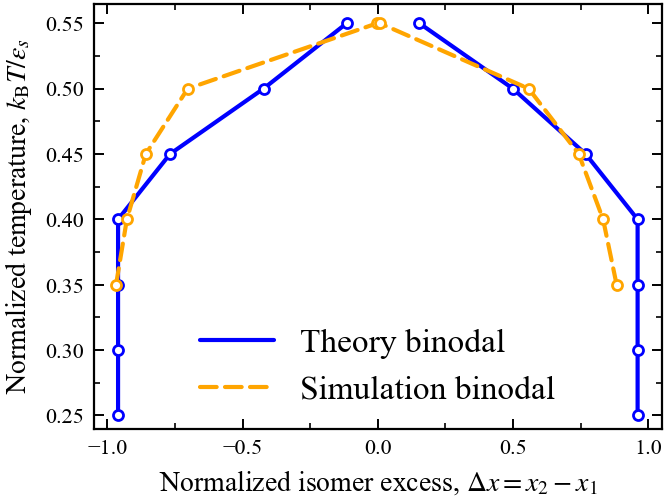

In [9]:
# --------------------------------------------------------------------------
# PRL-quality single-panel version (same data logic, just cleaned plotting)
# - APS-ish fonts/ticks
# - no grid (or very faint if you insist)
# - consistent markers/lines, no marker-edge "halos"
# - avoids vertical end artifacts (no forced smoothing xlim; no closure segments)
# --------------------------------------------------------------------------

import re, glob, json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from math import sqrt, pi
from scipy.optimize import least_squares
from scipy.ndimage import gaussian_filter1d

# -------------------- PRL/APS-ish style --------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------- helpers (your code, unchanged logic) --------------------

def tune_field_zero_mean_m(
    counts: np.ndarray,
    *,
    idx_A: Tuple[int, int] = (0, 4),
    idx_B: Tuple[int, int] = (4, 8),
    beta: float = 1.0,
    target_mean_m: float = 0.0,
    max_expand: int = 60,
    max_bisect: int = 80,
    tol: float = 1e-10,
    clip_logw: float = 80.0,
) -> Dict[str, float]:
    """
    Given per-sample species counts (n_samples, n_species), find a scalar field delta
    such that reweighting by w = exp(beta * delta * (N_B - N_A)) makes <m> = target_mean_m,
    where m = (N_B - N_A) / V and V = total counts per sample (assumed constant).

    idx_A and idx_B are half-open ranges selecting the ABEE and BAEE blocks.

    Returns dict with:
      - delta: tuned field
      - V: inferred volume
      - mean_m0: unweighted mean m
      - mean_m: reweighted mean m at delta
      - Neff: effective sample size at delta
    """
    counts = np.asarray(counts, dtype=float)
    if counts.ndim != 2 or counts.shape[0] == 0:
        raise ValueError("counts must be 2D (n_samples, n_species)")

    V = float(np.round(np.mean(np.sum(counts, axis=1))))
    NA = np.sum(counts[:, idx_A[0]:idx_A[1]], axis=1)
    NB = np.sum(counts[:, idx_B[0]:idx_B[1]], axis=1)
    dN = (NB - NA).astype(float)
    m = dN / V

    def weighted_mean_m(delta: float) -> Tuple[float, float]:
        logw = beta * delta * dN
        logw = np.clip(logw, -clip_logw, clip_logw)
        w = np.exp(logw)
        sw = float(np.sum(w))
        if sw == 0 or not np.isfinite(sw):
            return float("nan"), 0.0
        mean_m = float(np.sum(w * m) / sw)
        # Kish effective sample size
        Neff = float((sw * sw) / np.sum(w * w))
        return mean_m, Neff

    # Root function
    def f(delta: float) -> float:
        mu, _ = weighted_mean_m(delta)
        return mu - float(target_mean_m)

    mean_m0 = float(np.mean(m))

    # Bracket root by expanding symmetric interval
    a, b = -1e-6, 1e-6
    fa, fb = f(a), f(b)
    k = 0
    while np.sign(fa) == np.sign(fb) and k < max_expand:
        a *= 2.0
        b *= 2.0
        fa, fb = f(a), f(b)
        k += 1

    if not (np.isfinite(fa) and np.isfinite(fb)) or np.sign(fa) == np.sign(fb):
        # Fallback: if mean is already near target, return 0.
        mu0, Neff0 = weighted_mean_m(0.0)
        return {
            "delta": 0.0,
            "V": V,
            "mean_m0": mean_m0,
            "mean_m": float(mu0),
            "Neff": float(Neff0),
        }

    # Bisection
    lo, hi = a, b
    flo, fhi = fa, fb
    for _ in range(max_bisect):
        mid = 0.5 * (lo + hi)
        fmid = f(mid)
        if abs(fmid) <= tol:
            lo = hi = mid
            break
        if np.sign(fmid) == np.sign(flo):
            lo, flo = mid, fmid
        else:
            hi, fhi = mid, fmid

    delta_star = 0.5 * (lo + hi)
    mu_star, Neff_star = weighted_mean_m(delta_star)
    return {
        "delta": float(delta_star),
        "V": V,
        "mean_m0": mean_m0,
        "mean_m": float(mu_star),
        "Neff": float(Neff_star),
    }

def smooth_histogram_gaussian(x_centers, p_hist, sigma=1.0):
    x_centers = np.asarray(x_centers, float)
    p_hist    = np.asarray(p_hist, float)
    dx = float(np.mean(np.diff(x_centers)))
    if not np.allclose(np.diff(x_centers), dx, rtol=1e-4, atol=1e-8):
        raise ValueError("x_centers must be uniformly spaced.")
    sigma_bins = sigma / dx
    halfw = int(np.ceil(4 * sigma_bins))
    kx = np.arange(-halfw, halfw + 1, dtype=float)
    K = np.exp(-0.5 * (kx / sigma_bins)**2); K /= K.sum()
    p_pad = np.pad(p_hist, (halfw, halfw), mode='reflect')
    p_conv = np.convolve(p_pad, K, mode='same')[halfw:-halfw]
    p_conv /= np.trapezoid(p_conv, x_centers)
    return x_centers, p_conv

def centers_to_edges(centers):
    centers = np.asarray(centers, float)
    mids = 0.5*(centers[1:] + centers[:-1])
    first = centers[0] - (mids[0] - centers[0])
    last  = centers[-1] + (centers[-1] - mids[-1])
    return np.concatenate([[first], mids, [last]])

def _as_param_vec(params):
    if isinstance(params, dict):
        return np.array([params["w"], params["mu1"], params["mu2"],
                         params["sigma1"], params["sigma2"]], dtype=float)
    return np.asarray(params, dtype=float)


def parse_T_from_fname(fname: str) -> float:
    # Accept: ..._T0.5_..., ..._T0.50_..., ..._T05_...
    m = re.search(r"_T([0-9]+(?:\.[0-9]+)?)_", fname)
    if m is not None:
        return float(m.group(1))

    # Backward-compat: ..._T05_... or ..._T075_... meaning 0.5, 0.75, etc.
    m = re.search(r"_T(\d+)_", fname)
    if m is None:
        raise ValueError(f"Could not parse T from filename: {fname}")
    s = m.group(1)
    return int(s) / (10 ** (len(s) - 1))
# -------------------- SIM binodals from baseline files --------------------
sim_binodals = {}  # {T: (phi_neg, phi_pos)}

baseline_files = glob.glob('../data/baseline_hist_big*.json')
for fname in baseline_files:
    T = parse_T_from_fname(fname)


    with open(fname, 'r') as f:
        data = json.load(f)

    if not ("centers" in data and "counts" in data):
        continue

    centers = np.asarray(data["centers"], dtype=float)
    counts  = np.asarray(data["counts"], dtype=float)

    if "m" in data:
        m_samples = np.asarray(data["m"], dtype=float)
    else:
        V = float(np.round(np.mean(np.sum(counts, axis=1))))
        dN = np.sum(counts[:, 4:8], axis=1) - np.sum(counts[:, 0:4], axis=1)
        m_samples = dN / V

    dx = float(np.mean(np.diff(centers)))
    edges = centers_to_edges(centers)

    beta = 1.0 / T
    tuned = tune_field_zero_mean_m(counts, beta=beta, target_mean_m=0.0)
    delta = float(tuned["delta"])

    dN = np.sum(counts[:, 4:8], axis=1) - np.sum(counts[:, 0:4], axis=1)
    logw = np.clip(beta * delta * dN, -80.0, 80.0)
    w = np.exp(logw)

    hist_w, _ = np.histogram(m_samples, bins=edges, weights=w)
    pdf = hist_w / (np.sum(w) * dx)

    sigma = max(2.0 * dx, 0.01)
    _, H_smooth = smooth_histogram_gaussian(centers, pdf, sigma=sigma)

    if not ((centers < 0).any() and (centers > 0).any()):
        continue

    neg_mask = centers < 0.0
    pos_mask = centers > 0.0
    mu1= (centers[neg_mask])[np.argmax(H_smooth[neg_mask])]
    mu2= (centers[pos_mask])[np.argmax(H_smooth[pos_mask])]
    sim_binodals[T] = (min(mu1, mu2), max(mu1, mu2))

# -------------------- THEORY binodals from your NPZ results --------------------
files = [
    ("../data/spinodal_results_small4_canon_boundary_corr.npz",
     "../data/spinodal_metadata_small4_canon_boundary_corr.json", True, False),
]

# load_spinodal_results must already exist in your namespace
all_data = {}
for npz_file, json_file, compress, edges in files:
    spinodal, bounds, binodals, metadata = load_spinodal_results(
        filename=npz_file, metadata_filename=json_file, load_rhos=False
    )
    all_data[(compress, edges)] = dict(binodals=binodals, npz_file=npz_file)

compress, edges = (True, False)
data = all_data[(compress, edges)]
binodals = data["binodals"]

with np.load(data["npz_file"], allow_pickle=True) as z:
    Ts = z["Ts"]

phi1_list, phi2_list, T_list = [], [], []
for j, bd in enumerate(binodals):
    if not (bd is not None and isinstance(bd, dict)):
        continue
    phi1 = bd.get("phi1", np.nan)
    phi2 = bd.get("phi2", np.nan)
    if np.isnan(phi1) or np.isnan(phi2):
        continue
    if Ts[j] == 0.675:
        continue
    # your mapping to "Excess Δφ" (keep)
    phi1_list.append(0.5 - 2*phi1)
    phi2_list.append(0.5 - 2*phi2)
    T_list.append(Ts[j])

phi1_arr = np.array(phi1_list)
phi2_arr = np.array(phi2_list)
T_arr    = np.array(T_list)

sort_idx = np.argsort(T_arr)
T_arr = T_arr[sort_idx]
phi1_arr = phi1_arr[sort_idx]
phi2_arr = phi2_arr[sort_idx]

# normalize like your plot
x_th_L = phi1_arr/0.5
x_th_R = phi2_arr/0.5
y_th   = T_arr/2

# sim arrays
if len(sim_binodals) > 0:
    T_sim = np.array(sorted(sim_binodals.keys()))
    phi_sim = np.array([sim_binodals[T] for T in T_sim], float)
    x_sim_L = phi_sim[:, 0]/0.5
    x_sim_R = phi_sim[:, 1]/0.5
    y_sim   = T_sim/2
else:
    x_sim_L = x_sim_R = y_sim = None

# -------------------- PRL-quality plot --------------------
fig = plt.figure(figsize=(3.375, 2.55), dpi=200, constrained_layout=True)
ax = fig.add_subplot(111)

# Theory: lines + small filled markers
ax.plot(x_th_L, y_th, "-", c='blue',label="Theory binodal")
ax.plot(x_th_R, y_th, "-", c='blue',label="_nolegend_")
ax.plot(x_th_L, y_th, "o", c='blue', markersize=3.6, markerfacecolor="white", markeredgewidth=1.0)
ax.plot(x_th_R, y_th, "o", c='blue', markersize=3.6, markerfacecolor="white", markeredgewidth=1.0)

# Simulation: dashed lines + small filled markers
if x_sim_L is not None:
    dash = (0, (4, 2))
    ax.plot(x_sim_L, y_sim, linestyle=dash,c='orange', label="Simulation binodal")
    ax.plot(x_sim_R, y_sim, linestyle=dash,c='orange', label="_nolegend_")
    ax.plot(x_sim_L, y_sim, "o", markersize=3.6,c='orange', markerfacecolor="white", markeredgewidth=1.0)
    ax.plot(x_sim_R, y_sim, "o", markersize=3.6,c='orange', markerfacecolor="white", markeredgewidth=1.0)

# Labels (PRL)
ax.set_xlabel(
    r"Normalized isomer excess, $\Delta x = x_2 - x_1$",
    fontsize=10
)
ax.set_ylabel(r"Normalized temperature, $k_{\mathrm{B}}T/\epsilon_s$",fontsize=10)

# Ticks & spines
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which="both", top=True, right=True)

# Limits: keep your current view; adjust if needed
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(0.24, 0.565)

# Legend placed to avoid covering curves
ax.legend(loc="lower center", handlelength=2.2, borderaxespad=0.3,fontsize=12)

# No grid for PRL; if you insist, use VERY faint:
# ax.grid(True, which="major", linewidth=0.35, alpha=0.15)

#fig.savefig("../figures/binodal_excess_prl.pdf")
#fig.savefig("../figures/binodal_excess_prl.png", dpi=600)
plt.show()
